In [1]:
# Dependencias

# Manipulación de datos y utilidades
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import shap

# Machine Learning - Preprocesamiento y Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Machine Learning - Modelos
from xgboost import XGBClassifier

# Machine Learning - Evaluación y Selección de Modelos
from sklearn.model_selection import TimeSeriesSplit, cross_validate, learning_curve
from sklearn.metrics import (
    make_scorer, 
    f1_score, 
    precision_score, 
    recall_score, 
    classification_report, 
    ConfusionMatrixDisplay, 
    roc_curve, 
    auc, 
    RocCurveDisplay
)

In [ ]:
# Conexión a BigQuery
from google.cloud import bigquery
client = bigquery.Client(project='project3grupo1')

In [ ]:
# Cargamos los datos
query = """
WITH listings_dedup AS (
    SELECT *
    FROM `project3grupo1.airbnb_raw.listings`
    QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY snapshot_date DESC) = 1
),

events_agg AS (
    SELECT 
        start_date,
        COUNTIF(category = 'sports') as num_sports,
        COUNTIF(category = 'festivals') as num_festivals,
        SUM(phq_attendance) as total_attendance
    FROM `project3grupo1.airbnb_features.events`
    GROUP BY start_date
),

holidays_valencia AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_features.holidays`
    WHERE applies_to_valencia = True
),

calendar_dates AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_raw.calendar`
),

days_to_holiday AS (
    SELECT
        cd.date,
        MIN(DATE_DIFF(h.date, cd.date, DAY)) as days_to_next_holiday
    FROM calendar_dates cd
    LEFT JOIN holidays_valencia h ON h.date >= cd.date
    GROUP BY cd.date
)

SELECT
    -- Target
    CASE WHEN c.available = False THEN 1 ELSE 0 END as is_occupied,

    -- Temporales
    c.date,
    EXTRACT(MONTH FROM c.date) as month,
    EXTRACT(DAYOFWEEK FROM c.date) as day_of_week,
    IF(EXTRACT(DAYOFWEEK FROM c.date) IN (1,7), 1, 0) as is_weekend,
    COALESCE(dh.days_to_next_holiday, 0) as days_to_next_holiday,
    IF(h.date IS NOT NULL, 1, 0) as is_holiday,

    -- Del piso
    l.neighbourhood_cleansed,
    l.room_type,
    l.accommodates,
    l.price as listing_price,
    l.minimum_nights,
    l.number_of_reviews,
    l.review_scores_rating,
    IF(l.number_of_reviews > 0, 1, 0) as has_reviews,
    l.instant_bookable,

    -- Meteorología
    w.temp_mean,
    w.precipitation_mm,

    -- Eventos
    COALESCE(e.num_sports, 0) as num_sports,
    COALESCE(e.num_festivals, 0) as num_festivals,
    COALESCE(e.total_attendance, 0) as total_attendance

FROM `project3grupo1.airbnb_raw.calendar` c
LEFT JOIN listings_dedup l ON c.listing_id = l.id
LEFT JOIN `project3grupo1.airbnb_features.weather` w ON c.date = w.date
LEFT JOIN events_agg e ON c.date = e.start_date
LEFT JOIN holidays_valencia h ON c.date = h.date
LEFT JOIN days_to_holiday dh ON c.date = dh.date
WHERE c.date <= '2026-05-19'
QUALIFY ROW_NUMBER() OVER (PARTITION BY c.listing_id, c.date ORDER BY c.date DESC) = 1
"""

df = client.query(query).to_dataframe()
print(f'Shape: {df.shape}')
print(f'Nulos:\n{df.isnull().sum()}')

# Guardar como Parquet 
df.to_parquet('datos_airbnb.parquet', index=False)

In [3]:
# Cargamos desde Parquet
df = pd.read_parquet('datos_airbnb.parquet')
print(f'Shape: {df.shape}')
print(f'Rango de fechas: {df["date"].min()} → {df["date"].max()}')

Shape: (3376585, 21)
Rango de fechas: 2025-06-23 00:00:00 → 2026-05-19 00:00:00


In [4]:
# Split temporal
df['date'] = pd.to_datetime(df['date'])
train_end = '2026-02-28'
test_start = '2026-03-01'

df_train = df[df['date'] <= train_end].copy()
df_test  = df[df['date'] >= test_start].copy()

print(f'Train: {df_train.shape[0]:,} filas  ({df_train["date"].min().date()} → {df_train["date"].max().date()})')
print(f'Test : {df_test.shape[0]:,} filas  ({df_test["date"].min().date()} → {df_test["date"].max().date()})')

print(f'\nDistribución target train: {df_train["is_occupied"].mean():.3f}')
print(f'Distribución target test : {df_test["is_occupied"].mean():.3f}')

Train: 2,394,745 filas  (2025-06-23 → 2026-02-28)
Test : 981,840 filas  (2026-03-01 → 2026-05-19)

Distribución target train: 0.394
Distribución target test : 0.323


In [5]:
# Flag binario de presencia/ausencia de reseñas
df_train['has_reviews'] = df_train['review_scores_rating'].notna().astype(int)
df_test['has_reviews']  = df_test['review_scores_rating'].notna().astype(int)


# Aplicamos las siguientes transformaciones iterando sobre ambos sets (train y test)
for df in [df_train, df_test]:
    # Codificación temporal cíclica
    # Usamos seno y coseno para que el modelo entienda que diciembre (mes 12) y enero (mes 1) son contiguos temporalmente
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Ponemos un tope de 14 días a la cercanía del próximo festivo
    # Asumimos que si faltan más de dos semanas, el efecto en la ocupación es nulo
    # Esto reduce el ruido de valores extremos muy grandes
    df['days_to_next_holiday'] = df['days_to_next_holiday'].clip(upper=14)

    # Transformaciones de sesgo y relaciones de precio
    # Aplicamos log1p (logaritmo natural + 1) para "normalizar" variables con distribuciones muy sesgadas (colas largas hacia la derecha)
    df['log_price']      = np.log1p(df['listing_price'])
    df['log_reviews']    = np.log1p(df['number_of_reviews'])
    df['log_min_nights'] = np.log1p(df['minimum_nights'])
    
    # Calculamos el precio por persona. Reemplazamos posibles 0s en 'accommodates' por 1s de forma preventiva para evitar errores de división por cero.
    df['price_per_person'] = df['listing_price'] / df['accommodates'].replace(0, 1)

# Variable sintética de contexto espacial
# Calculamos el precio promedio histórico por barrio en el set de Train
neigh_mean_price = df_train.groupby('neighbourhood_cleansed')['listing_price'].mean()

for df in [df_train, df_test]:
    # Mapeamos ese promedio aprendido a ambos sets y lo comparamos con el precio real
    # Si un barrio no estaba en train (poco probable pero posible), rellenamos con 1
    df['price_vs_neigh_mean'] = df['listing_price'] / df['neighbourhood_cleansed'].map(neigh_mean_price).fillna(1)

    # Variables de eventos y asistemcia
    # Simplificamos el conteo de eventos a variables binarias de presencia
    df['has_sports_event'] = (df['num_sports'] > 0).astype(int)
    df['has_festival']     = (df['num_festivals'] > 0).astype(int)

    # Aplicamos logaritmo a la asistencia total por su altísima varianza
    df['log_attendance'] = np.log1p(df['total_attendance'])

In [6]:
# Features finales 
FEATURES = [
    # Temporales (cíclicas sustituyen a month y day_of_week)
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'days_to_next_holiday', 'is_holiday',
    # Listing
    'neighbourhood_cleansed', 'room_type', 'accommodates',
    'log_price', 'price_per_person', 'price_vs_neigh_mean',
    'log_min_nights',
    # Reseñas
    'log_reviews', 'review_scores_rating', 'has_reviews',
    # Reserva
    'instant_bookable',
    # Clima
    'temp_mean', 'precipitation_mm',
    # Eventos
    'num_sports', 'num_festivals',
    'log_attendance', 'has_sports_event', 'has_festival',
]

TARGET = 'is_occupied'

num_cols = [
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'days_to_next_holiday', 'is_holiday',
    'accommodates', 'log_price', 'price_per_person', 'price_vs_neigh_mean',
    'log_min_nights',
    'log_reviews', 'review_scores_rating', 'has_reviews',
    'instant_bookable',
    'temp_mean',
    'num_sports', 'num_festivals',
    'log_attendance', 'has_sports_event', 'has_festival',
]

cat_cols = ['neighbourhood_cleansed', 'room_type']

keep = FEATURES + [TARGET]
df_train = df_train[keep].copy()
df_test  = df_test[keep].copy()

print(f'Total features: {len(FEATURES)}')
print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')

Total features: 25
Train: (2394745, 26)  |  Test: (981840, 26)


In [7]:
# Pipeline exclusivo para los datos de texto/categorías
categorical_pipeline = Pipeline([
    # Imputación: Rellenamos nulos con la categoría más frecuente (la moda)
    ('imputer', SimpleImputer(strategy='most_frequent')),
    
    # Codificación One-Hot: Convertimos texto a columnas de ceros y unos
    # drop='first': Evita multicolinealidad
    # handle_unknown='ignore': Evita errores si aparecen nuevas categorías en Test
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

# A diferencia de Redes Neuronales o KNN, los algoritmos basados en árboles (como XGBoost) 
# no realizan cálculos de distancias espaciales. El orden relativo de los datos no cambia al escalarlos, 
# por lo que omitir el StandardScaler ahorra tiempo de cómputo, simplifica el pipeline y mantiene 
# las reglas del modelo 100% interpretables para negocio.

preprocessor = ColumnTransformer([
    ('cat', categorical_pipeline, cat_cols),
    
], remainder='passthrough') 
# remainder='passthrough' le dice al transformador que las columnas que no están en 'cat_cols' (nuestras variables numéricas crudas) deben pasar intactas

X_train = df_train[FEATURES]
y_train = df_train[TARGET].astype(int) 

X_test  = df_test[FEATURES]
y_test  = df_test[TARGET].astype(int)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'Train: {X_train_processed.shape}')
print(f'Test : {X_test_processed.shape}')

Train: (2394745, 94)
Test : (981840, 94)


In [8]:
# Entrenamos el modelo final
ratio = float((y_train == 0).sum() / (y_train == 1).sum())

best_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.157,
    subsample=0.871,
    colsample_bytree=0.931,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

best_model.fit(X_train_processed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.931
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

              precision    recall  f1-score   support

       libre       0.82      0.81      0.82    664672
     ocupado       0.61      0.63      0.62    317168

    accuracy                           0.75    981840
   macro avg       0.72      0.72      0.72    981840
weighted avg       0.75      0.75      0.75    981840



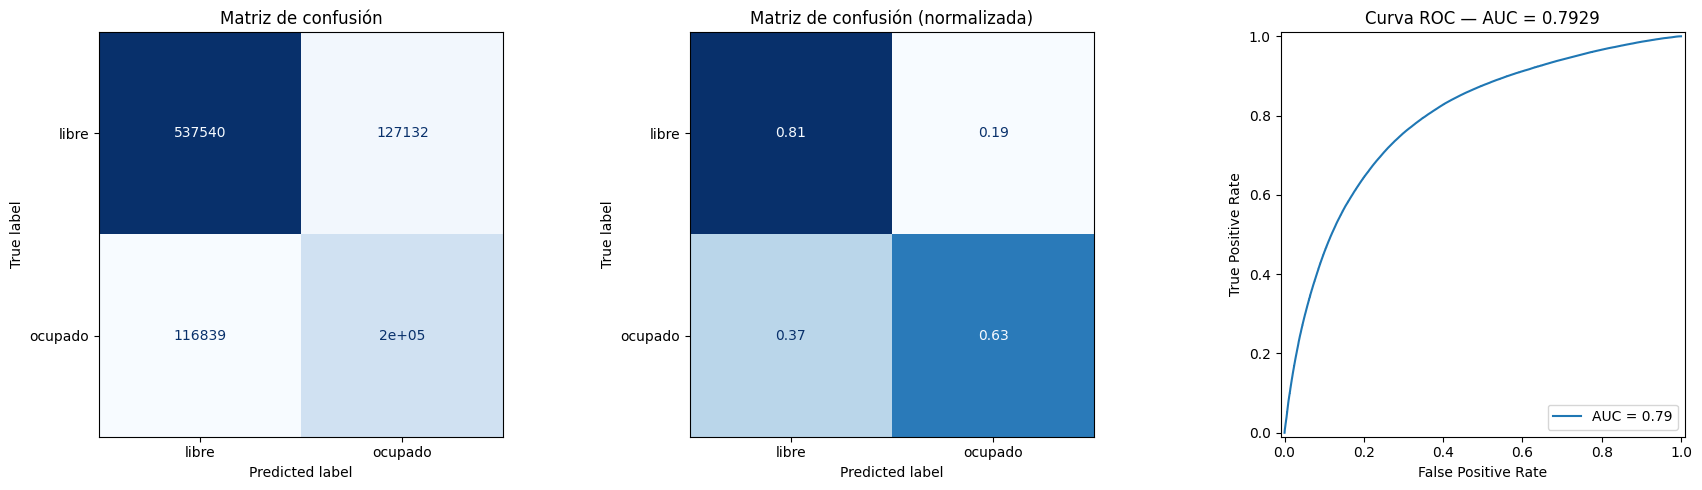

In [9]:
y_pred  = best_model.predict(X_test_processed)
y_proba = best_model.predict_proba(X_test_processed)[:, 1]

print(classification_report(y_test, y_pred, target_names=['libre', 'ocupado'], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], cmap='Blues',
    colorbar=False, display_labels=['libre', 'ocupado']
)
axes[0].set_title('Matriz de confusión')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[1], cmap='Blues',
    colorbar=False, normalize='true', display_labels=['libre', 'ocupado']
)
axes[1].set_title('Matriz de confusión (normalizada)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=axes[2])
axes[2].set_title(f'Curva ROC — AUC = {roc_auc:.4f}')

plt.tight_layout()
plt.show()

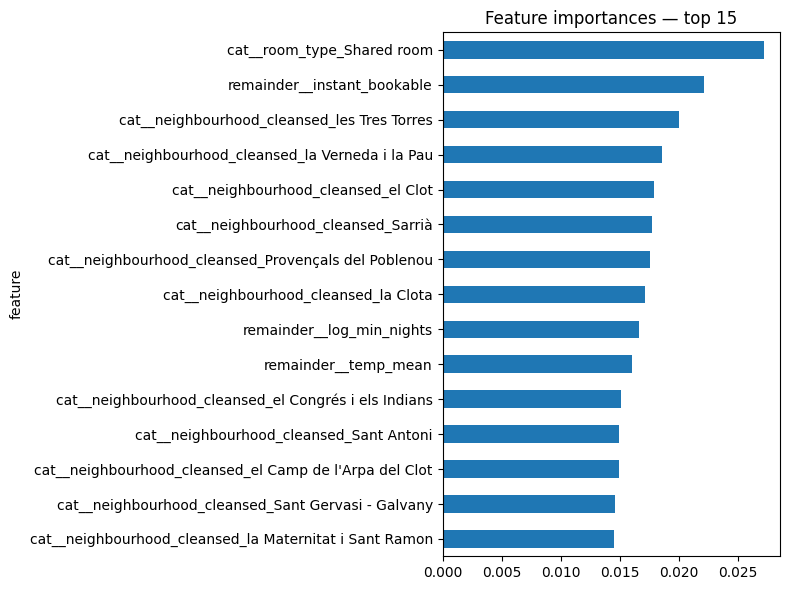

                                               feature  importance
                            cat__room_type_Shared room    0.027201
                           remainder__instant_bookable    0.022123
           cat__neighbourhood_cleansed_les Tres Torres    0.019994
       cat__neighbourhood_cleansed_la Verneda i la Pau    0.018566
                   cat__neighbourhood_cleansed_el Clot    0.017880
                    cat__neighbourhood_cleansed_Sarrià    0.017728
   cat__neighbourhood_cleansed_Provençals del Poblenou    0.017525
                  cat__neighbourhood_cleansed_la Clota    0.017144
                             remainder__log_min_nights    0.016627
                                  remainder__temp_mean    0.016065
  cat__neighbourhood_cleansed_el Congrés i els Indians    0.015079
               cat__neighbourhood_cleansed_Sant Antoni    0.014917
cat__neighbourhood_cleansed_el Camp de l'Arpa del Clot    0.014914
    cat__neighbourhood_cleansed_Sant Gervasi - Galvany    0.01

In [10]:
feature_names = preprocessor.get_feature_names_out()

fi_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False)

fi_df.head(15).plot(
    kind='barh', x='feature', y='importance',
    figsize=(8, 6), title='Feature importances — top 15', legend=False
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(fi_df.head(15).to_string(index=False))

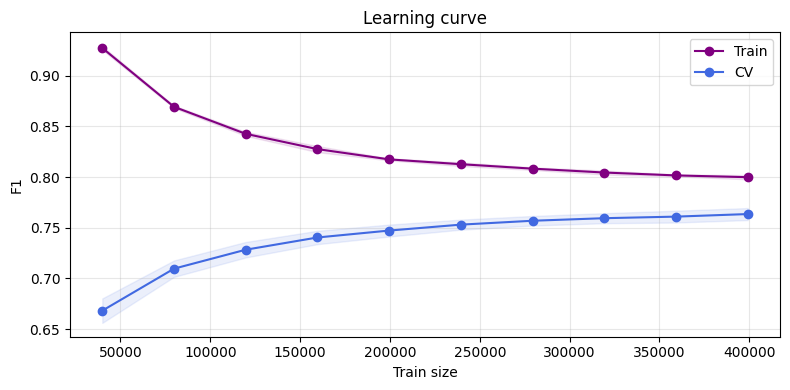

Gap final (F1 train − CV): 0.0364


In [11]:
cv = TimeSeriesSplit(n_splits=5)

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_processed, y_train,
    cv=cv, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, shuffle=True, random_state=42
)

tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, tm, 'o-', color='purple',    label='Train')
ax.plot(train_sizes, vm, 'o-', color='royalblue', label='CV')
ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.1, color='purple')
ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.1, color='royalblue')
ax.set(xlabel='Train size', ylabel='F1', title='Learning curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gap final (F1 train − CV): {tm[-1] - vm[-1]:.4f}')

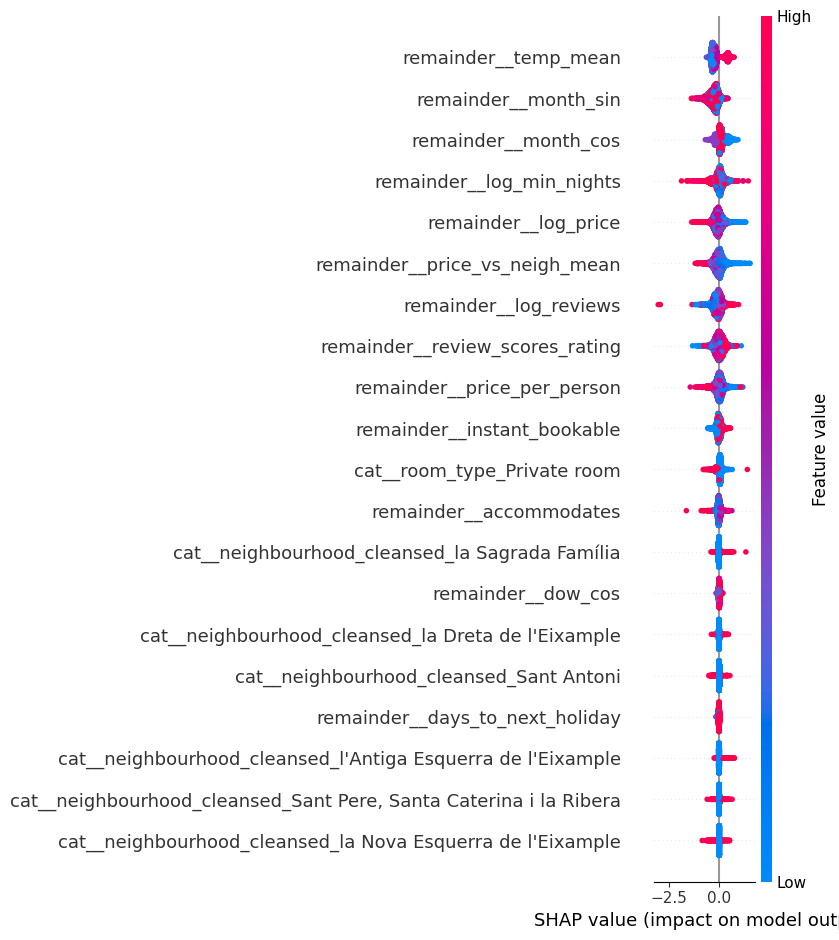

In [12]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_processed[:5000])

shap.summary_plot(shap_values, X_test_processed[:5000], feature_names=feature_names)

In [16]:
import pickle
from google.cloud import storage

# Guardar los tres artefactos
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

neigh_mean_price.to_json('neigh_mean_price.json')